In [26]:
import torch
import matplotlib.pyplot as plt
import numpy as np  
import math
import random
import graphviz

In [47]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.label = label
        self._prev = set(_children)
        self._op = _op
        self.grad = 0.0
        self._backward = lambda:None

    def __repr__(self):
        return f"Value(data = {self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward # Assign tthe backward to the output value so that it can be called later during backpropagation.

        return out
    
    def __radd__(self, other):
        return self + other # This allows for scalar addition from the left (e.g., 2 + Value)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other # This allows for scalar multiplication from the left (e.g., 2 * Value)
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other ** -1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - (t ** 2)) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        # Topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [28]:
from graphviz import Digraph
import graphviz

def trace(root):
    nodes = set()
    edges = set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = graphviz.Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            op_uid = uid + n._op
            dot.node(op_uid, n._op)
            dot.edge(op_uid, uid)
        for child in n._prev:
            dot.edge(str(id(child)), uid + n._op)
    return dot

In [33]:
x1 = Value(2.0, label = 'x1')
x2 = Value(3.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(-1.0, label = 'w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2. label = 'x1w1x2w2'

n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()

o = (e + 1) / (e - 1)

o.label = 'o'


In [34]:
o.grad = 1.0
o.backward()

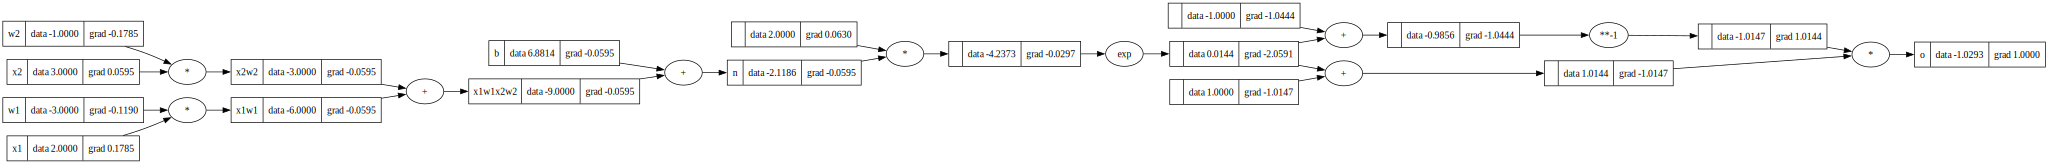

In [35]:

draw_dot(o)

In [36]:
# PyTorch Implementation

x1 = torch.tensor([2.0]).double()                       ; x1.requires_grad = True
x2 = torch.tensor([0.0]).double()                       ; x2.requires_grad = True
w1 = torch.tensor([-3.0]).double()                      ; w1.requires_grad = True
w2 = torch.tensor([1.0]).double()                       ; w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double()         ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print(x1.grad.data.item())
print(x2.grad.data.item())
print(w1.grad.data.item())
print(w2.grad.data.item())

0.7071066904050358
-1.5000003851533106
0.5000001283844369
1.0000002567688737
0.0


In [48]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((xi*wi for xi,wi in zip(self.w, x)), self.b)
        out = act.tanh()

        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]

        return outs
    
    def parameters(self):
        return [ p for n in self.neurons for p in n.parameters()]
    
class MLP:
    def __init__(self, nin, nout):
        sz = [nin] + nout
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nout))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0]
    def parameters(self):
        return [p for n in self.layers for p in n.parameters()]
    
        

In [49]:
x = [2.0, 3.0, -1.0]
mlp = MLP(3, [4, 4, 1])  # Assuming you want an MLP with 3 inputs, 2 hidden layers of 4 neurons each, and 1 output
out = mlp(x)

In [50]:
mlp.parameters()

[Value(data = 0.3859516908670573),
 Value(data = 0.2404892138383552),
 Value(data = -0.5320938335059604),
 Value(data = -0.20341229349021828),
 Value(data = 0.4927693590369093),
 Value(data = 0.4362482926853144),
 Value(data = 0.6431689501334108),
 Value(data = -0.6023934862520699),
 Value(data = 0.7484727624527638),
 Value(data = 0.15012256960498616),
 Value(data = 0.15188273458134627),
 Value(data = -0.5347896802302947),
 Value(data = -0.07990378966191858),
 Value(data = -0.5257683501267378),
 Value(data = -0.06633602921272441),
 Value(data = 0.8963558011603228),
 Value(data = 0.9339635794729939),
 Value(data = -0.5613825405844524),
 Value(data = 0.6477989874615848),
 Value(data = -0.22764862458697088),
 Value(data = 0.5290144240728103),
 Value(data = 0.5451110594630466),
 Value(data = 0.970171983331916),
 Value(data = -0.9142469071167425),
 Value(data = 0.7510964742570818),
 Value(data = 0.6465763773856728),
 Value(data = -0.6676766868379858),
 Value(data = 0.9386411006755284),
 Val

In [51]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [52]:
ypreds = [mlp(x) for x in xs]
ypreds

[Value(data = 0.9621683204141748),
 Value(data = 0.979388121253773),
 Value(data = 0.9139115979160904),
 Value(data = 0.9662639672503194)]

In [53]:
# Loss Function
loss = sum((yout - ygt) ** 2 for ygt,yout in zip(ys, ypreds))
loss

Value(data = 7.583604295084236)

In [54]:
loss.backward()

In [55]:
mlp.layers[0].neurons[0].w[0]

Value(data = 0.3859516908670573)

In [57]:
for p in mlp.parameters():
    p.data += -0.05 * p.grad

In [58]:
mlp.layers[0].neurons[0].w[0]

Value(data = 0.36462001859156007)

In [97]:
for k in range(20):
    ypreds = [mlp(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for yout,ygt in zip(ypreds, ys))

    for p in mlp.parameters():
        p.grad = 0.0 
    
    loss.backward()

    for p in mlp.parameters():
        p.data += -0.01 * p.grad

    print(f"step {k:02d} | loss {loss.data:.4f} | w[0].grad {mlp.layers[0].neurons[0].w[0].grad:.6f}")

step 00 | loss 0.0044 | w[0].grad -0.000668
step 01 | loss 0.0044 | w[0].grad -0.000666
step 02 | loss 0.0043 | w[0].grad -0.000665
step 03 | loss 0.0043 | w[0].grad -0.000664
step 04 | loss 0.0043 | w[0].grad -0.000663
step 05 | loss 0.0043 | w[0].grad -0.000662
step 06 | loss 0.0043 | w[0].grad -0.000660
step 07 | loss 0.0043 | w[0].grad -0.000659
step 08 | loss 0.0043 | w[0].grad -0.000658
step 09 | loss 0.0043 | w[0].grad -0.000657
step 10 | loss 0.0043 | w[0].grad -0.000656
step 11 | loss 0.0043 | w[0].grad -0.000655
step 12 | loss 0.0043 | w[0].grad -0.000653
step 13 | loss 0.0043 | w[0].grad -0.000652
step 14 | loss 0.0043 | w[0].grad -0.000651
step 15 | loss 0.0043 | w[0].grad -0.000650
step 16 | loss 0.0043 | w[0].grad -0.000649
step 17 | loss 0.0043 | w[0].grad -0.000648
step 18 | loss 0.0042 | w[0].grad -0.000647
step 19 | loss 0.0042 | w[0].grad -0.000645


In [99]:
ypreds

[Value(data = 0.9664452992219623),
 Value(data = -0.9763080291746227),
 Value(data = -0.959080534850838),
 Value(data = 0.9703988202074217)]